# EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df_salary = pd.read_csv('ds_salaries.csv')

# Drop the confusing and useless columns
cols_to_drop = ['salary', 'salary_currency', 'employment_type']
df_salary = df_salary.drop(columns=cols_to_drop, errors='ignore')

# 3. Let's look at the Job Titles before we visualize
print("Top 10 most common job titles:")
print(df_salary['job_title'].value_counts().head(10))

Top 10 most common job titles:
job_title
Data Engineer                1040
Data Scientist                840
Data Analyst                  612
Machine Learning Engineer     289
Analytics Engineer            103
Data Architect                101
Research Scientist             82
Data Science Manager           58
Applied Scientist              58
Research Engineer              37
Name: count, dtype: int64


* Drop the salary and salary_currency columns.
Reason: Local currency salaries range from 30,000 to 30,000,000 depending on the country's exchange rate. This confuses both humans and machine learning models. We will keep ONLY salary_in_usd.
*  Drop the employment_type column.
Reason: 99.01% of the records are "Full-Time". Because there is basically no variety, this column gives us zero predictive power.
* Keep work_year.
Reason: Inflation and the tech boom heavily affect salaries.


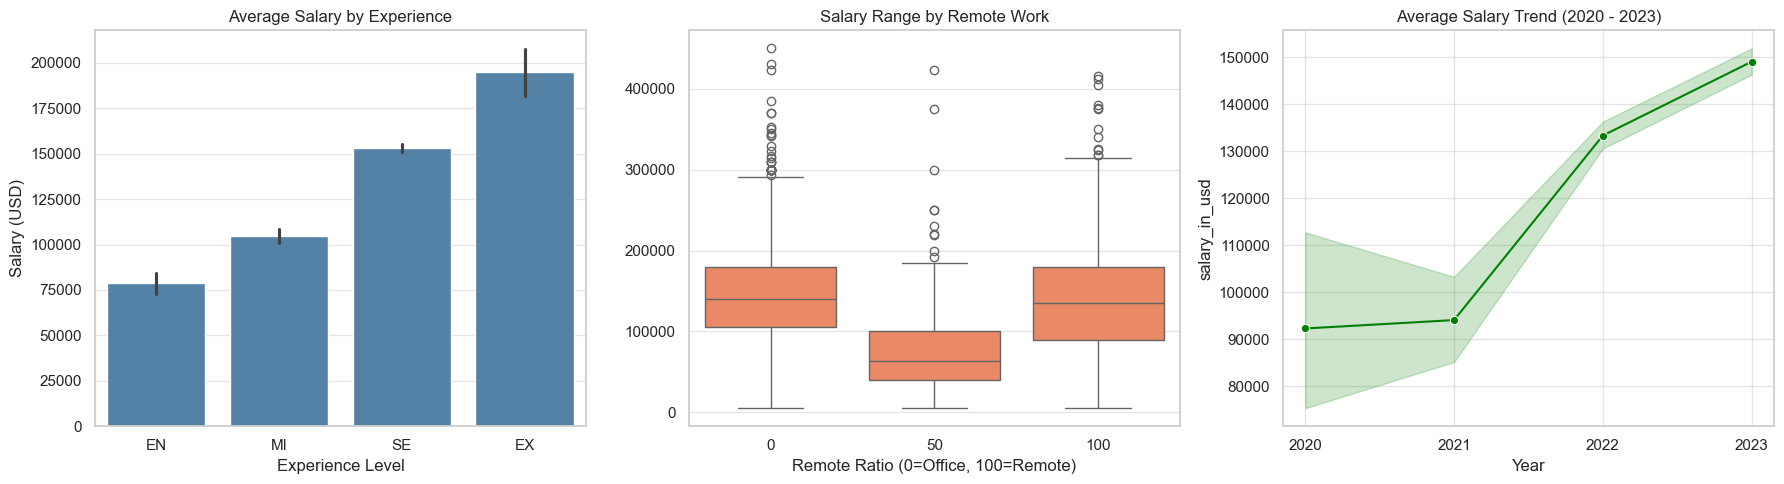

In [4]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

# Experience vs Salary
plt.subplot(1, 3, 1)
sns.barplot(data=df_salary, x='experience_level', y='salary_in_usd', order=['EN', 'MI', 'SE', 'EX'], color='steelblue')
plt.title('Average Salary by Experience')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')

# Remote Ratio vs Salary
plt.subplot(1, 3, 2)
# 0 = On-site, 50 = Hybrid, 100 = Fully Remote
sns.boxplot(data=df_salary, x='remote_ratio', y='salary_in_usd', color='coral')
plt.title('Salary Range by Remote Work')
plt.xlabel('Remote Ratio (0=Office, 100=Remote)')
plt.ylabel('')

# Salary Trends Over Time
plt.subplot(1, 3, 3)
sns.lineplot(data=df_salary, x='work_year', y='salary_in_usd', marker='o', color='green')
plt.title('Average Salary Trend (2020 - 2023)')
plt.xticks([2020, 2021, 2022, 2023])
plt.xlabel('Year')

plt.tight_layout()
plt.show()

### Findings:
1.  As expected, experience is the ultimate driver of pay. There is a clear, linear trend: (EN) is the baseline, moving to (MI), Senior (SE) roles see massive gains, and Executives (EX) top the charts.
2.  The data shows that Fully Remote (100) and On-Site (0) roles offer very competitive and similar salary ranges. However, Hybrid (50) roles actually pay noticeably less on average. This suggests that top-tier companies either pay a premium for in-office talent or hire fully remote global talent, while hybrid roles are often tied to smaller, local businesses.
3. The trendline from 2020 to 2023 salaries skyrocketed during this period, reflecting the massive hiring boom in Data Science, AI, and Machine Learning.

# Model Building

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_percentage_error, r2_score

df_salary = pd.read_csv('ds_salaries.csv')
df_salary = df_salary.drop_duplicates()

# Add Cross-border flag
df_salary['cross_border'] = (df_salary['employee_residence'] != df_salary['company_location']).astype(int)

# Group Job Titles (Top 15)
top_15_titles = df_salary['job_title'].value_counts().head(15).index
df_salary['job_title_clean'] = df_salary['job_title'].apply(lambda x: x if x in top_15_titles else 'Other')

# Group Locations (Top 4)
top_4_locs = df_salary['company_location'].value_counts().head(4).index
df_salary['company_location_clean'] = df_salary['company_location'].apply(lambda x: x if x in top_4_locs else 'Other')

top_4_res = df_salary['employee_residence'].value_counts().head(4).index
df_salary['employee_residence_clean'] = df_salary['employee_residence'].apply(lambda x: x if x in top_4_res else 'Other')


X = df_salary[['experience_level', 'remote_ratio', 'work_year', 'job_title_clean',
               'company_location_clean', 'employee_residence_clean', 'cross_border']]

# Log-transform the target salary
y_log = np.log(df_salary['salary_in_usd'])

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_log = ridge_model.predict(X_test)
y_pred_dollars = np.exp(y_pred_log)
y_test_dollars = np.exp(y_test_log)

print(f"Honest Ridge R-squared Score: {r2_score(y_test_log, y_pred_log):.3f}")
print(f"MAPE (Mean Absolute Percentage Error): {mean_absolute_percentage_error(y_test_dollars, y_pred_dollars):.1%}")

Honest Ridge R-squared Score: 0.581
MAPE (Mean Absolute Percentage Error): 37.9%
